In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc
from matplotlib import rc_context
import anndata as ad
import gc

In [29]:
# suppress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [30]:
sc.set_figure_params(vector_friendly=True, dpi_save=600) 

In [31]:
sns.set_theme(style='white')

In [32]:
df_metrics = pd.read_csv('tables/benchmark_results_all_gptcelltype_deepseek.csv', comment='#')
metadata = pd.read_excel('tables/Table S1.xlsx')
metadata.rename(columns={'Dataset No.': 'dataset'}, inplace=True)
df_metrics = df_metrics.join(metadata.set_index('dataset'), on='dataset')

In [33]:
df_metrics.loc[df_metrics.method == 'deepseek', 'method'] = 'scExtract'
df_metrics.loc[df_metrics.method == 'deepseek_no_context', 'method'] = 'scExtract (no context)'

In [34]:
df_metrics

,dataset,method,n_cells,real_cell_types,predicted_cell_types,average_accuracy,group_accuracy,ARI,low_certainty_accuracy,medium_certainty_accuracy,...,very_rare_accuracy,batch_std,within_batch_var,total_var,batch_effect_ratio,Article,cellxgene Link,Processing Details,Raw Data,Tissue
0,sample16,singleR,66780,9,18,0.569176,0.519180,0.587863,0.459216,0.539929,...,0.436258,0.022511,0.011847,0.012053,0.982979,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
1,sample16,GPTCelltype,66465,9,13,0.583894,0.539408,0.829652,0.354764,0.715609,...,0.479172,0.015860,0.009011,0.008885,1.014163,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
2,sample16,scExtract,66465,9,13,0.721383,0.622115,0.829652,0.164273,0.780990,...,0.509118,0.027419,0.018808,0.018531,1.014924,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
3,sample16,scExtract (no context),66465,9,13,0.620193,0.658800,0.829652,0.315591,0.934804,...,0.685513,0.034039,0.034550,0.034124,1.012483,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
4,sample17,singleR,50905,8,32,0.418132,0.476740,0.266536,0.307201,NaN,...,NaN,0.037851,0.032994,0.032144,1.026457,Single-nucleus chromatin accessibility and tra...,https://cellxgene.cziscience.com/collections/7...,"No author defined cell type, using standard ce...",GSE244594,breast upper outer quadrant of breast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,sample5,scExtract (no context),62707,11,9,0.532161,0.672544,0.157102,NaN,0.400356,...,0.827180,0.205909,0.016837,0.039897,0.422010,Identification of distinct tumor cell populati...,https://cellxgene.cziscience.com/collections/a...,"No author defined cell type, using standard ce...",GSE180665,liver
68,sample21,singleR,41648,21,16,0.505911,0.533388,0.332270,0.450580,NaN,...,0.645511,0.018665,0.009948,0.009161,1.085844,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
69,sample21,GPTCelltype,41648,21,19,0.586890,0.527469,0.678980,NaN,0.480128,...,0.542408,0.014210,0.012847,0.011231,1.143875,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
70,sample21,scExtract,41648,21,19,0.787637,0.672403,0.474963,NaN,0.725092,...,0.536325,0.065807,0.031748,0.032164,0.987056,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues


In [35]:
df_metrics.columns

Index(['dataset', 'method', 'n_cells', 'real_cell_types',
       'predicted_cell_types', 'average_accuracy', 'group_accuracy', 'ARI',
       'low_certainty_accuracy', 'medium_certainty_accuracy',
       'high_certainty_accuracy', 'common_accuracy', 'rare_0.05_accuracy',
       'rare_0.01_accuracy', 'very_rare_accuracy', 'batch_std',
       'within_batch_var', 'total_var', 'batch_effect_ratio', 'Article',
       'cellxgene Link', 'Processing Details', 'Raw Data', 'Tissue'],
      dtype='object')

In [36]:
df_metrics

,dataset,method,n_cells,real_cell_types,predicted_cell_types,average_accuracy,group_accuracy,ARI,low_certainty_accuracy,medium_certainty_accuracy,...,very_rare_accuracy,batch_std,within_batch_var,total_var,batch_effect_ratio,Article,cellxgene Link,Processing Details,Raw Data,Tissue
0,sample16,singleR,66780,9,18,0.569176,0.519180,0.587863,0.459216,0.539929,...,0.436258,0.022511,0.011847,0.012053,0.982979,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
1,sample16,GPTCelltype,66465,9,13,0.583894,0.539408,0.829652,0.354764,0.715609,...,0.479172,0.015860,0.009011,0.008885,1.014163,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
2,sample16,scExtract,66465,9,13,0.721383,0.622115,0.829652,0.164273,0.780990,...,0.509118,0.027419,0.018808,0.018531,1.014924,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
3,sample16,scExtract (no context),66465,9,13,0.620193,0.658800,0.829652,0.315591,0.934804,...,0.685513,0.034039,0.034550,0.034124,1.012483,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
4,sample17,singleR,50905,8,32,0.418132,0.476740,0.266536,0.307201,NaN,...,NaN,0.037851,0.032994,0.032144,1.026457,Single-nucleus chromatin accessibility and tra...,https://cellxgene.cziscience.com/collections/7...,"No author defined cell type, using standard ce...",GSE244594,breast upper outer quadrant of breast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,sample5,scExtract (no context),62707,11,9,0.532161,0.672544,0.157102,NaN,0.400356,...,0.827180,0.205909,0.016837,0.039897,0.422010,Identification of distinct tumor cell populati...,https://cellxgene.cziscience.com/collections/a...,"No author defined cell type, using standard ce...",GSE180665,liver
68,sample21,singleR,41648,21,16,0.505911,0.533388,0.332270,0.450580,NaN,...,0.645511,0.018665,0.009948,0.009161,1.085844,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
69,sample21,GPTCelltype,41648,21,19,0.586890,0.527469,0.678980,NaN,0.480128,...,0.542408,0.014210,0.012847,0.011231,1.143875,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
70,sample21,scExtract,41648,21,19,0.787637,0.672403,0.474963,NaN,0.725092,...,0.536325,0.065807,0.031748,0.032164,0.987056,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues


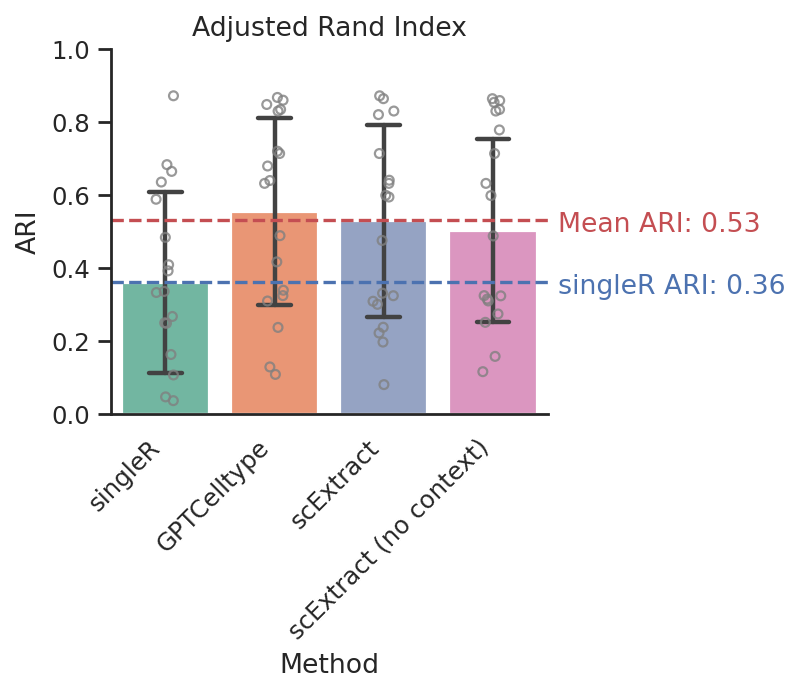

In [37]:
order = ['singleR', 'GPTCelltype', 'scExtract (no context)', 'scExtract']
with rc_context({'figure.figsize': (3.5, 3)}):
    g = sns.barplot(data=df_metrics, x='method', y='ARI', 
                        ci="sd", palette='Set2', order=order,
                        capsize=0.3, errwidth=2, dodge=True)
    sns.stripplot(data=df_metrics, x='method', y='ARI', size=5, alpha=0.8, color='gray', marker="$\circ$")
    g.set_title('Adjusted Rand Index')
    g.set_ylabel('ARI')
    g.set_xlabel('Method')
    sns.despine()
    g.yaxis.set_ticks_position('left')
    g.set_ylim(0, 1)
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')

    # calculate mean of ARI
    mean_ari_marker_gene = df_metrics[df_metrics['method'].isin(['GPTCelltype', 'scExtract (no context)', 'scExtract'])]['ARI'].mean()
    mean_ari_marker_gene = round(mean_ari_marker_gene, 2)
    # add horizontal line for mean ARI
    plt.axhline(y=mean_ari_marker_gene, color='r', linestyle='--')
    plt.text(3.6, mean_ari_marker_gene-0.03, f'Mean ARI: {mean_ari_marker_gene}', color='r')

    mean_ari_marker_gene = df_metrics[df_metrics['method'].isin(['singleR'])]['ARI'].mean()
    mean_ari_marker_gene = round(mean_ari_marker_gene, 2)
    # add horizontal line for mean ARI
    plt.axhline(y=mean_ari_marker_gene, color='b', linestyle='--')
    plt.text(3.6, mean_ari_marker_gene-0.03, f'singleR ARI: {mean_ari_marker_gene}', color='b')
    # plt.savefig('figures_revision/GPTct/ARI_comparison.pdf', bbox_inches='tight')
    plt.show()

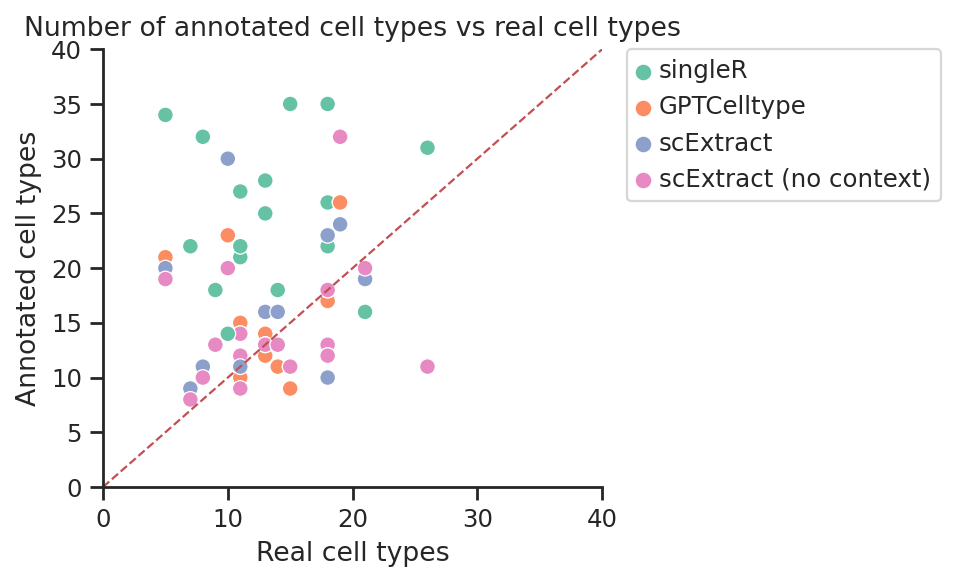

In [38]:
with rc_context({'figure.figsize': (4, 3.6)}):
    g = sns.scatterplot(data=df_metrics, x='real_cell_types', y='predicted_cell_types', hue='method', s=50, palette='Set2')
    # set legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    sns.despine()
    g.set_xlim(0, 40)
    g.set_ylim(0, 40)
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    # line
    x = np.linspace(0, 40, 10)
    y = x
    plt.plot(x, y, 'r--', linewidth=1)
    g.set_title('Number of annotated cell types vs real cell types')
    g.set_xlabel('Real cell types')
    g.set_ylabel('Annotated cell types')
    # plt.savefig('figures_revision/GPTct/Number_of_annotated_cell_types_vs_real_cell_types.pdf', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_1656303/1824436863.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = df_metrics.groupby('method').apply(


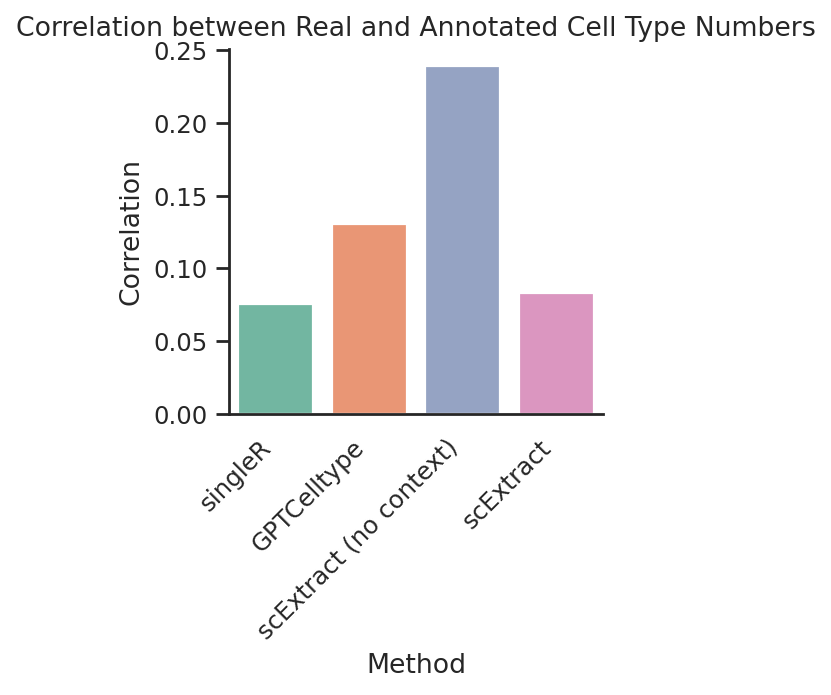

In [39]:
with rc_context({'figure.figsize': (3, 3)}):
    # Calculate correlation for each LLM
    correlations = df_metrics.groupby('method').apply(
        lambda x: x['real_cell_types'].corr(x['predicted_cell_types'], method='pearson')
    )
    # methods = ['GPTCelltype', 'scExtract (no context)', 'scExtract']
    g = sns.barplot(x=correlations.index, y=correlations.values, order=order, palette='Set2')
    g.set_title('Correlation between Real and Annotated Cell Type Numbers')
    g.set_xlabel('Method')
    g.set_ylabel('Correlation')
    g.yaxis.set_ticks_position('left')
    # g.xaxis.set_ticks_position('bottom')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    # g.set_ylim(0, 1)
    sns.despine()
    # plt.savefig('figures_revision/GPTct/Correlation_between_Real_and_Annotated_Cell_Type_Numbers_for_Each_LLM.pdf', bbox_inches='tight')
    plt.show()

### Similarity

In [40]:
df_metrics.columns

Index(['dataset', 'method', 'n_cells', 'real_cell_types',
       'predicted_cell_types', 'average_accuracy', 'group_accuracy', 'ARI',
       'low_certainty_accuracy', 'medium_certainty_accuracy',
       'high_certainty_accuracy', 'common_accuracy', 'rare_0.05_accuracy',
       'rare_0.01_accuracy', 'very_rare_accuracy', 'batch_std',
       'within_batch_var', 'total_var', 'batch_effect_ratio', 'Article',
       'cellxgene Link', 'Processing Details', 'Raw Data', 'Tissue'],
      dtype='object')

In [41]:
# create palette for Tissue
palette = sns.color_palette("tab20", 20)
palette = palette[:len(df_metrics['Tissue'].unique())]
tissue_palette = dict(zip(df_metrics['Tissue'].unique(), palette))

In [42]:
sns.set_theme(style='white')

In [43]:
df_metrics

,dataset,method,n_cells,real_cell_types,predicted_cell_types,average_accuracy,group_accuracy,ARI,low_certainty_accuracy,medium_certainty_accuracy,...,very_rare_accuracy,batch_std,within_batch_var,total_var,batch_effect_ratio,Article,cellxgene Link,Processing Details,Raw Data,Tissue
0,sample16,singleR,66780,9,18,0.569176,0.519180,0.587863,0.459216,0.539929,...,0.436258,0.022511,0.011847,0.012053,0.982979,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
1,sample16,GPTCelltype,66465,9,13,0.583894,0.539408,0.829652,0.354764,0.715609,...,0.479172,0.015860,0.009011,0.008885,1.014163,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
2,sample16,scExtract,66465,9,13,0.721383,0.622115,0.829652,0.164273,0.780990,...,0.509118,0.027419,0.018808,0.018531,1.014924,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
3,sample16,scExtract (no context),66465,9,13,0.620193,0.658800,0.829652,0.315591,0.934804,...,0.685513,0.034039,0.034550,0.034124,1.012483,Multiomic Profiling of Human Clonal Hematopoie...,https://cellxgene.cziscience.com/collections/0...,"No author defined cell type, using standard ce...",NaN,blood
4,sample17,singleR,50905,8,32,0.418132,0.476740,0.266536,0.307201,NaN,...,NaN,0.037851,0.032994,0.032144,1.026457,Single-nucleus chromatin accessibility and tra...,https://cellxgene.cziscience.com/collections/7...,"No author defined cell type, using standard ce...",GSE244594,breast upper outer quadrant of breast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,sample5,scExtract (no context),62707,11,9,0.532161,0.672544,0.157102,NaN,0.400356,...,0.827180,0.205909,0.016837,0.039897,0.422010,Identification of distinct tumor cell populati...,https://cellxgene.cziscience.com/collections/a...,"No author defined cell type, using standard ce...",GSE180665,liver
68,sample21,singleR,41648,21,16,0.505911,0.533388,0.332270,0.450580,NaN,...,0.645511,0.018665,0.009948,0.009161,1.085844,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
69,sample21,GPTCelltype,41648,21,19,0.586890,0.527469,0.678980,NaN,0.480128,...,0.542408,0.014210,0.012847,0.011231,1.143875,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues
70,sample21,scExtract,41648,21,19,0.787637,0.672403,0.474963,NaN,0.725092,...,0.536325,0.065807,0.031748,0.032164,0.987056,Distinct microbial and immune niches of the hu...,https://cellxgene.cziscience.com/collections/7...,Manually expand author cell type,E-MTAB-8007,4 tissues


In [44]:
methods = order

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Wilcoxon signed-rank test for GPTCelltype and scExtract (no context):
Statistic: 12.0000
p-value: 0.0005

Wilcoxon signed-rank test for GPTCelltype and scExtract:
Statistic: 7.0000
p-value: 0.0001


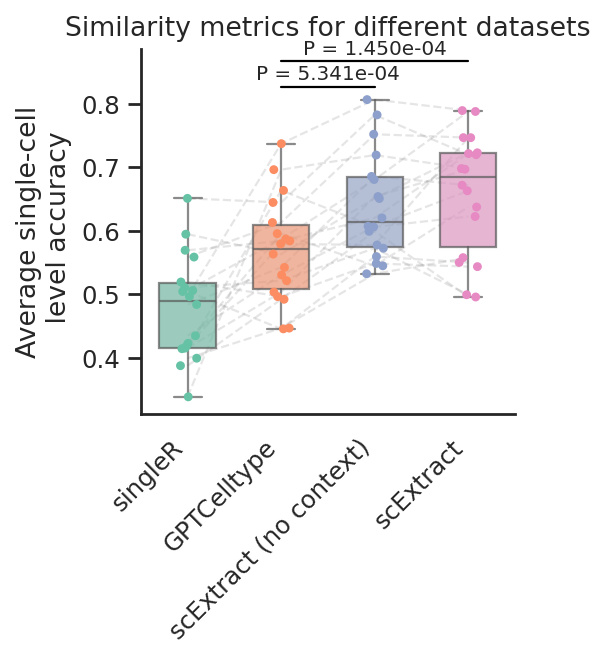

In [45]:
from scipy import stats

with plt.rc_context({'figure.figsize': [3, 3]}):
    g = sns.boxplot(data=df_metrics, x='method', y='average_accuracy', order=methods,
                    palette='Set2',
                    width=0.6,
                    linewidth=1,
                    boxprops={'alpha': 0.7},
                    whiskerprops={'alpha': 0.7},
                    capprops={'alpha': 0.7},
                    medianprops={'alpha': 0.7},
                    fliersize=0)
    
    # Create stripplot first to get the points
    points = sns.stripplot(data=df_metrics, x='method', y='average_accuracy', 
                         palette='Set2', order=methods, dodge=True, 
                         marker='o', alpha=1, size=4)
    
    # Connect points with the same dataset
    # First get mapping of method names to x-positions
    method_positions = {method: i for i, method in enumerate(methods)}
    
    # Group by dataset and draw lines connecting points from the same dataset
    for dataset in df_metrics['dataset'].unique():
        dataset_points = df_metrics[df_metrics['dataset'] == dataset]
        
        # For each dataset, get points for each method and connect them
        # Sort by method to ensure correct line connections
        dataset_points = dataset_points.sort_values('method', key=lambda x: [methods.index(val) if val in methods else len(methods) for val in x])
        
        if len(dataset_points) > 1:  # Only draw lines if we have at least 2 points
            x_positions = [method_positions[method] for method in dataset_points['method']]
            y_values = dataset_points['average_accuracy'].values
            
            plt.plot(x_positions, y_values, color='gray', alpha=0.2, linewidth=1, zorder=0, linestyle='--')
    
    # Define the pairs to compare
    pairs = [('GPTCelltype', 'scExtract (no context)'), ('GPTCelltype', 'scExtract')]
    
    # Get max y for vertical position of brackets
    y_max = df_metrics['average_accuracy'].max()
    bracket_heights = [y_max + 0.02, y_max + 0.06]  # Different heights for different pairs
    
    # Calculate and display p-values for specified pairs
    for i, (method1, method2) in enumerate(pairs):
        # Get data for each method
        method1_data = df_metrics[df_metrics['method'] == method1].sort_values('dataset')['average_accuracy'].values
        method2_data = df_metrics[df_metrics['method'] == method2].sort_values('dataset')['average_accuracy'].values
        
        # Perform Wilcoxon signed-rank test
        statistic, p_value = stats.wilcoxon(method1_data, method2_data)
        
        print(f"\nWilcoxon signed-rank test for {method1} and {method2}:")
        print(f"Statistic: {statistic:.4f}")
        print(f"p-value: {p_value:.4f}")
        
        # Get x-positions for both methods
        method1_idx = methods.index(method1)
        method2_idx = methods.index(method2)
        
        p_text = f"P = {p_value:.3e}"
            
        # Calculate positions for the bracket and text
        x_left = min(method1_idx, method2_idx)
        x_right = max(method1_idx, method2_idx)
        x_mid = (x_left + x_right) / 2
        y_height = bracket_heights[i]
        
        # Draw bracket
        plt.plot([x_left, x_right], 
                 [y_height, y_height], 
                 color='black', linewidth=1)
        
        # Add p-value text
        plt.text(x_mid, y_height+0.005, p_text, ha='center', va='bottom', fontsize=9)
    
    # Calculate mean and SD for each group
    stats_df = df_metrics.groupby(['method'])['average_accuracy'].agg(['mean', 'std']).reset_index()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    g.yaxis.set_ticks_position('left')
    g.set_title('Similarity metrics for different datasets')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.set_ylabel('Average single-cell\n level accuracy')
    
    # Adjust y limit to accommodate the p-value text and brackets
    y_limit = bracket_heights[-1] + 0.02
    g.set_ylim(None, y_limit)
    g.set_xlabel('')
    plt.legend().remove()
    
    plt.savefig('figures_revision/GPTct/Deepseek_Similarity_metrics_for_different_datasets.pdf', bbox_inches='tight')
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Wilcoxon signed-rank test for GPTCelltype and scExtract (no context):
Statistic: 1.0000
p-value: 0.0000

Wilcoxon signed-rank test for GPTCelltype and scExtract:
Statistic: 12.0000
p-value: 0.0005


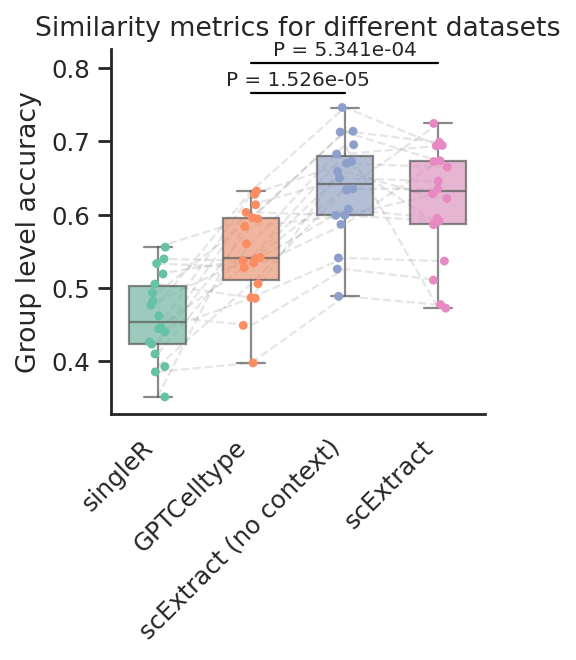

In [46]:
from scipy import stats

with plt.rc_context({'figure.figsize': [3, 3]}):
    g = sns.boxplot(data=df_metrics, x='method', y='group_accuracy', order=methods,
                    palette='Set2',
                    width=0.6,
                    linewidth=1,
                    boxprops={'alpha': 0.7},
                    whiskerprops={'alpha': 0.7},
                    capprops={'alpha': 0.7},
                    medianprops={'alpha': 0.7},
                    fliersize=0)
    
    # Create stripplot first to get the points
    points = sns.stripplot(data=df_metrics, x='method', y='group_accuracy', 
                         palette='Set2', order=methods, dodge=True, 
                         marker='o', alpha=1, size=4)
    
    # Connect points with the same dataset
    # First get mapping of method names to x-positions
    method_positions = {method: i for i, method in enumerate(methods)}
    
    # Group by dataset and draw lines connecting points from the same dataset
    for dataset in df_metrics['dataset'].unique():
        dataset_points = df_metrics[df_metrics['dataset'] == dataset]
        
        # For each dataset, get points for each method and connect them
        # Sort by method to ensure correct line connections
        dataset_points = dataset_points.sort_values('method', key=lambda x: [methods.index(val) if val in methods else len(methods) for val in x])
        
        if len(dataset_points) > 1:  # Only draw lines if we have at least 2 points
            x_positions = [method_positions[method] for method in dataset_points['method']]
            y_values = dataset_points['group_accuracy'].values
            
            plt.plot(x_positions, y_values, color='gray', alpha=0.2, linewidth=1, zorder=0, linestyle='--')
    
    # Define the pairs to compare
    pairs = [('GPTCelltype', 'scExtract (no context)'), ('GPTCelltype', 'scExtract')]
    
    # Get max y for vertical position of brackets
    y_max = df_metrics['group_accuracy'].max()
    bracket_heights = [y_max + 0.02, y_max + 0.06]  # Different heights for different pairs
    
    # Calculate and display p-values for specified pairs
    for i, (method1, method2) in enumerate(pairs):
        # Get data for each method
        method1_data = df_metrics[df_metrics['method'] == method1].sort_values('dataset')['group_accuracy'].values
        method2_data = df_metrics[df_metrics['method'] == method2].sort_values('dataset')['group_accuracy'].values
        
        # Perform Wilcoxon signed-rank test
        statistic, p_value = stats.wilcoxon(method1_data, method2_data)
        
        print(f"\nWilcoxon signed-rank test for {method1} and {method2}:")
        print(f"Statistic: {statistic:.4f}")
        print(f"p-value: {p_value:.4f}")
        
        # Get x-positions for both methods
        method1_idx = methods.index(method1)
        method2_idx = methods.index(method2)
        
        p_text = f"P = {p_value:.3e}"
            
        # Calculate positions for the bracket and text
        x_left = min(method1_idx, method2_idx)
        x_right = max(method1_idx, method2_idx)
        x_mid = (x_left + x_right) / 2
        y_height = bracket_heights[i]
        
        # Draw bracket
        plt.plot([x_left, x_right], 
                 [y_height, y_height], 
                 color='black', linewidth=1)
        
        # Add p-value text
        plt.text(x_mid, y_height+0.005, p_text, ha='center', va='bottom', fontsize=9)
    
    # Calculate mean and SD for each group
    stats_df = df_metrics.groupby(['method'])['group_accuracy'].agg(['mean', 'std']).reset_index()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    g.yaxis.set_ticks_position('left')
    g.set_title('Similarity metrics for different datasets')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.set_ylabel('Group level accuracy')
    
    # Adjust y limit to accommodate the p-value text and brackets
    y_limit = bracket_heights[-1] + 0.02
    g.set_ylim(None, y_limit)
    g.set_xlabel('')
    plt.legend().remove()
    
    plt.savefig('figures_revision/GPTct/Deepseek_Group_accuracy_metrics_for_different_datasets.pdf', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_1656303/959477420.py:11: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = g.legend_.legendHandles


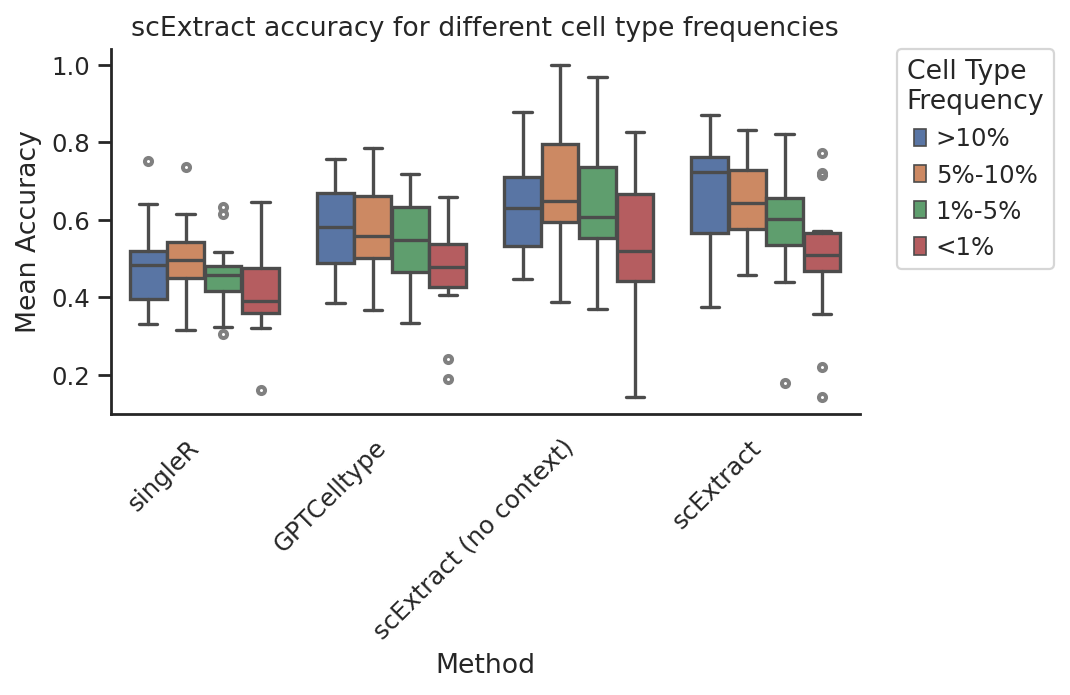

In [47]:
df_metrics_acc = df_metrics.loc[:, df_metrics.columns.str.contains('accuracy|dataset|method|Tissue')]
# df_metrics_acc = df_metrics_acc.loc[df_metrics_acc.method.isin(['deepseek v2.5', 'Claude 3.5', 'gpt4o_mini'])]
df_metrics_acc = df_metrics_acc.loc[:, ['dataset', 'method', 'common_accuracy', 'rare_0.05_accuracy', 'rare_0.01_accuracy', 'very_rare_accuracy']]
df_metrics_acc = df_metrics_acc.melt(id_vars=['dataset', 'method'], var_name='Certainty', value_name='Accuracy')

with plt.rc_context({'figure.figsize': [6, 3]}):
    g = sns.boxplot(data=df_metrics_acc, x='method', y='Accuracy', hue='Certainty', order=methods,
                    flierprops={'markerfacecolor': 'gray', 'markersize': 4,
                               'markeredgecolor': 'gray', 'marker': "$\circ$"},)
    sns.despine()
    handles = g.legend_.legendHandles
    plt.legend(handles=handles, labels=['>10%', '5%-10%', '1%-5%', '<1%'], 
               bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Cell Type\nFrequency')
    g.yaxis.set_ticks_position('left')
    g.set_title('scExtract accuracy for different cell type frequencies')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.set_ylabel('Mean Accuracy')
    g.set_xlabel('Method')
    # plt.savefig('figures_revision/GPTct/scExtract_accuracy_for_different_cell_type_frequencies.pdf', bbox_inches='tight')
    plt.show()

# Benchmark using OLS

In [48]:
df_metrics_ols = pd.read_csv('tables/benchmark_results_all_gptcelltype_deepseek_ols.csv', comment='#')
metadata = pd.read_excel('tables/Table S1.xlsx')
metadata.rename(columns={'Dataset No.': 'dataset'}, inplace=True)
df_metrics_ols = df_metrics_ols.join(metadata.set_index('dataset'), on='dataset')
df_metrics_ols.loc[df_metrics_ols.method == 'deepseek', 'method'] = 'scExtract'
df_metrics_ols.loc[df_metrics_ols.method == 'deepseek_no_context', 'method'] = 'scExtract (no context)'

In [49]:
# df = df_metrics_ols.pivot_table(index='dataset', columns='method', values='group_accuracy')
# (df['scExtract'] - df['GPTCelltype']).sort_values(ascending=False)

In [50]:
df_metrics_ols.pivot_table(index='dataset', columns='method', values='average_accuracy')

method,GPTCelltype,scExtract,scExtract (no context),singleR
dataset,,,,
sample1,0.631422,0.810310,0.717592,0.780631
sample10,0.457301,0.691184,0.633755,0.685327
sample11,0.548010,0.954941,0.559554,0.495846
sample12,0.488041,0.597373,0.500340,0.670546
sample14,0.790470,0.790470,0.717411,0.672731
sample16,0.773096,0.868705,0.664564,0.876471
sample17,0.435554,0.826551,0.639788,0.548847
sample18,0.692620,0.722606,0.528432,0.503887
sample19,0.520363,0.684305,0.683802,0.479679


/home/wu/mambaforge/envs/scanpy/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Wilcoxon signed-rank test for GPTCelltype and scExtract (no context):
Statistic: 56.0000
p-value: 0.2121

Wilcoxon signed-rank test for GPTCelltype and scExtract:
Statistic: 1.0000
p-value: 0.0004


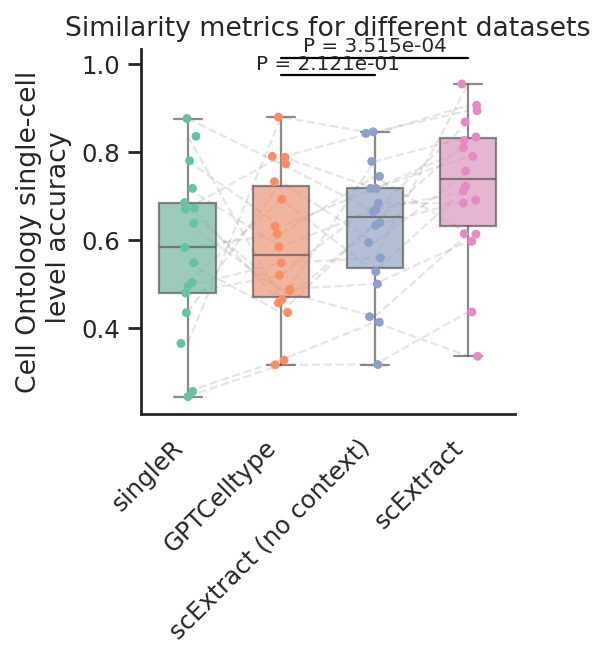

In [51]:
from scipy import stats

with plt.rc_context({'figure.figsize': [3, 3]}):
    g = sns.boxplot(data=df_metrics_ols, x='method', y='average_accuracy', order=methods,
                    palette='Set2',
                    width=0.6,
                    linewidth=1,
                    boxprops={'alpha': 0.7},
                    whiskerprops={'alpha': 0.7},
                    capprops={'alpha': 0.7},
                    medianprops={'alpha': 0.7},
                    fliersize=0)
    
    # Create stripplot first to get the points
    points = sns.stripplot(data=df_metrics_ols, x='method', y='average_accuracy', 
                         palette='Set2', order=methods, dodge=True, 
                         marker='o', alpha=1, size=4)
    
    # Connect points with the same dataset
    # First get mapping of method names to x-positions
    method_positions = {method: i for i, method in enumerate(methods)}
    
    # Group by dataset and draw lines connecting points from the same dataset
    for dataset in df_metrics_ols['dataset'].unique():
        dataset_points = df_metrics_ols[df_metrics_ols['dataset'] == dataset]
        
        # For each dataset, get points for each method and connect them
        # Sort by method to ensure correct line connections
        dataset_points = dataset_points.sort_values('method', key=lambda x: [methods.index(val) if val in methods else len(methods) for val in x])
        
        if len(dataset_points) > 1:  # Only draw lines if we have at least 2 points
            x_positions = [method_positions[method] for method in dataset_points['method']]
            y_values = dataset_points['average_accuracy'].values
            
            plt.plot(x_positions, y_values, color='gray', alpha=0.2, linewidth=1, zorder=0, linestyle='--')
    
    # Define the pairs to compare
    pairs = [('GPTCelltype', 'scExtract (no context)'), ('GPTCelltype', 'scExtract')]
    
    # Get max y for vertical position of brackets
    y_max = df_metrics_ols['average_accuracy'].max()
    bracket_heights = [y_max + 0.02, y_max + 0.06]  # Different heights for different pairs
    
    # Calculate and display p-values for specified pairs
    for i, (method1, method2) in enumerate(pairs):
        # Get data for each method
        method1_data = df_metrics_ols[df_metrics_ols['method'] == method1].sort_values('dataset')['average_accuracy'].values
        method2_data = df_metrics_ols[df_metrics_ols['method'] == method2].sort_values('dataset')['average_accuracy'].values
        
        # Perform Wilcoxon signed-rank test
        statistic, p_value = stats.wilcoxon(method1_data, method2_data)
        
        print(f"\nWilcoxon signed-rank test for {method1} and {method2}:")
        print(f"Statistic: {statistic:.4f}")
        print(f"p-value: {p_value:.4f}")
        
        # Get x-positions for both methods
        method1_idx = methods.index(method1)
        method2_idx = methods.index(method2)
        
        p_text = f"P = {p_value:.3e}"
            
        # Calculate positions for the bracket and text
        x_left = min(method1_idx, method2_idx)
        x_right = max(method1_idx, method2_idx)
        x_mid = (x_left + x_right) / 2
        y_height = bracket_heights[i]
        
        # Draw bracket
        plt.plot([x_left, x_right], 
                 [y_height, y_height], 
                 color='black', linewidth=1)
        
        # Add p-value text
        plt.text(x_mid, y_height+0.005, p_text, ha='center', va='bottom', fontsize=9)
    
    # Calculate mean and SD for each group
    stats_df = df_metrics_ols.groupby(['method'])['average_accuracy'].agg(['mean', 'std']).reset_index()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    g.yaxis.set_ticks_position('left')
    g.set_title('Similarity metrics for different datasets')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.set_ylabel('Cell Ontology single-cell\n level accuracy')
    
    # Adjust y limit to accommodate the p-value text and brackets
    y_limit = bracket_heights[-1] + 0.02
    g.set_ylim(None, y_limit)
    g.set_xlabel('')
    plt.legend().remove()
    
    plt.savefig('figures_revision/GPTct/Deepseek_CellOntology_accuracy_metrics.pdf', bbox_inches='tight')
    plt.show()

/home/wu/mambaforge/envs/scanpy/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Wilcoxon signed-rank test for GPTCelltype and scExtract (no context):
Statistic: 17.0000
p-value: 0.0016

Wilcoxon signed-rank test for GPTCelltype and scExtract:
Statistic: 0.0000
p-value: 0.0003


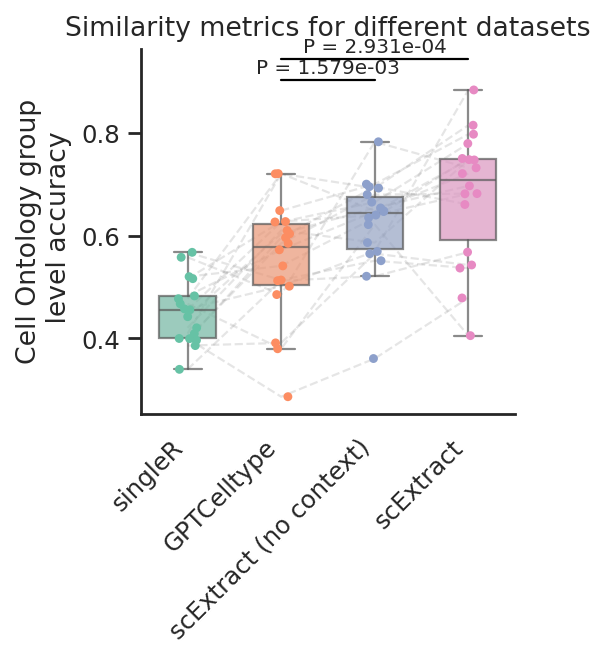

In [52]:
from scipy import stats

with plt.rc_context({'figure.figsize': [3, 3]}):
    g = sns.boxplot(data=df_metrics_ols, x='method', y='group_accuracy', order=methods,
                    palette='Set2',
                    width=0.6,
                    linewidth=1,
                    boxprops={'alpha': 0.7},
                    whiskerprops={'alpha': 0.7},
                    capprops={'alpha': 0.7},
                    medianprops={'alpha': 0.7},
                    fliersize=0)
    
    # Create stripplot first to get the points
    points = sns.stripplot(data=df_metrics_ols, x='method', y='group_accuracy', 
                         palette='Set2', order=methods, dodge=True, 
                         marker='o', alpha=1, size=4)
    
    # Connect points with the same dataset
    # First get mapping of method names to x-positions
    method_positions = {method: i for i, method in enumerate(methods)}
    
    # Group by dataset and draw lines connecting points from the same dataset
    for dataset in df_metrics_ols['dataset'].unique():
        dataset_points = df_metrics_ols[df_metrics_ols['dataset'] == dataset]
        
        # For each dataset, get points for each method and connect them
        # Sort by method to ensure correct line connections
        dataset_points = dataset_points.sort_values('method', key=lambda x: [methods.index(val) if val in methods else len(methods) for val in x])
        
        if len(dataset_points) > 1:  # Only draw lines if we have at least 2 points
            x_positions = [method_positions[method] for method in dataset_points['method']]
            y_values = dataset_points['group_accuracy'].values
            
            plt.plot(x_positions, y_values, color='gray', alpha=0.2, linewidth=1, zorder=0, linestyle='--')
    
    # Define the pairs to compare
    pairs = [('GPTCelltype', 'scExtract (no context)'), ('GPTCelltype', 'scExtract')]
    
    # Get max y for vertical position of brackets
    y_max = df_metrics_ols['group_accuracy'].max()
    bracket_heights = [y_max + 0.02, y_max + 0.06]  # Different heights for different pairs
    
    # Calculate and display p-values for specified pairs
    for i, (method1, method2) in enumerate(pairs):
        # Get data for each method
        method1_data = df_metrics_ols[df_metrics_ols['method'] == method1].sort_values('dataset')['group_accuracy'].values
        method2_data = df_metrics_ols[df_metrics_ols['method'] == method2].sort_values('dataset')['group_accuracy'].values
        
        # Perform Wilcoxon signed-rank test
        statistic, p_value = stats.wilcoxon(method1_data, method2_data)
        
        print(f"\nWilcoxon signed-rank test for {method1} and {method2}:")
        print(f"Statistic: {statistic:.4f}")
        print(f"p-value: {p_value:.4f}")
        
        # Get x-positions for both methods
        method1_idx = methods.index(method1)
        method2_idx = methods.index(method2)
        
        p_text = f"P = {p_value:.3e}"
            
        # Calculate positions for the bracket and text
        x_left = min(method1_idx, method2_idx)
        x_right = max(method1_idx, method2_idx)
        x_mid = (x_left + x_right) / 2
        y_height = bracket_heights[i]
        
        # Draw bracket
        plt.plot([x_left, x_right], 
                 [y_height, y_height], 
                 color='black', linewidth=1)
        
        # Add p-value text
        plt.text(x_mid, y_height+0.005, p_text, ha='center', va='bottom', fontsize=9)
    
    # Calculate mean and SD for each group
    stats_df = df_metrics_ols.groupby(['method'])['group_accuracy'].agg(['mean', 'std']).reset_index()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    g.yaxis.set_ticks_position('left')
    g.set_title('Similarity metrics for different datasets')
    g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
    g.set_ylabel('Cell Ontology group\n level accuracy')
    
    # Adjust y limit to accommodate the p-value text and brackets
    y_limit = bracket_heights[-1] + 0.02
    g.set_ylim(None, y_limit)
    g.set_xlabel('')
    plt.legend().remove()
    
    plt.savefig('figures_revision/GPTct/Deepseek_CellOntology_group_accuracy_metrics.pdf', bbox_inches='tight')
    plt.show()